## Visualizing the results of prediction interval models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from pyhere import here

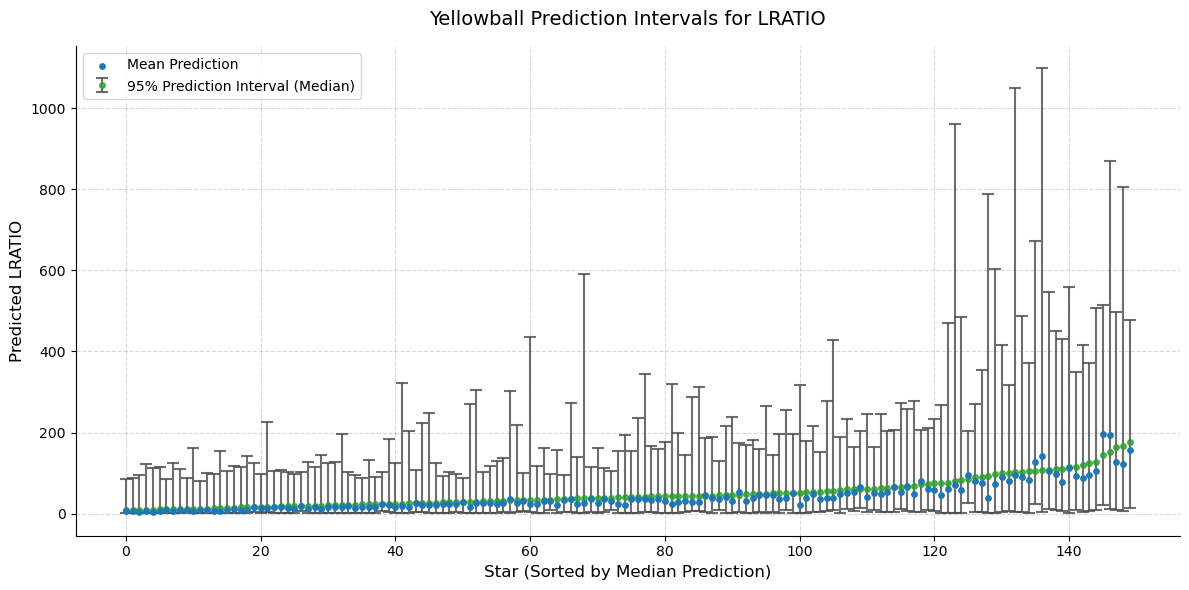

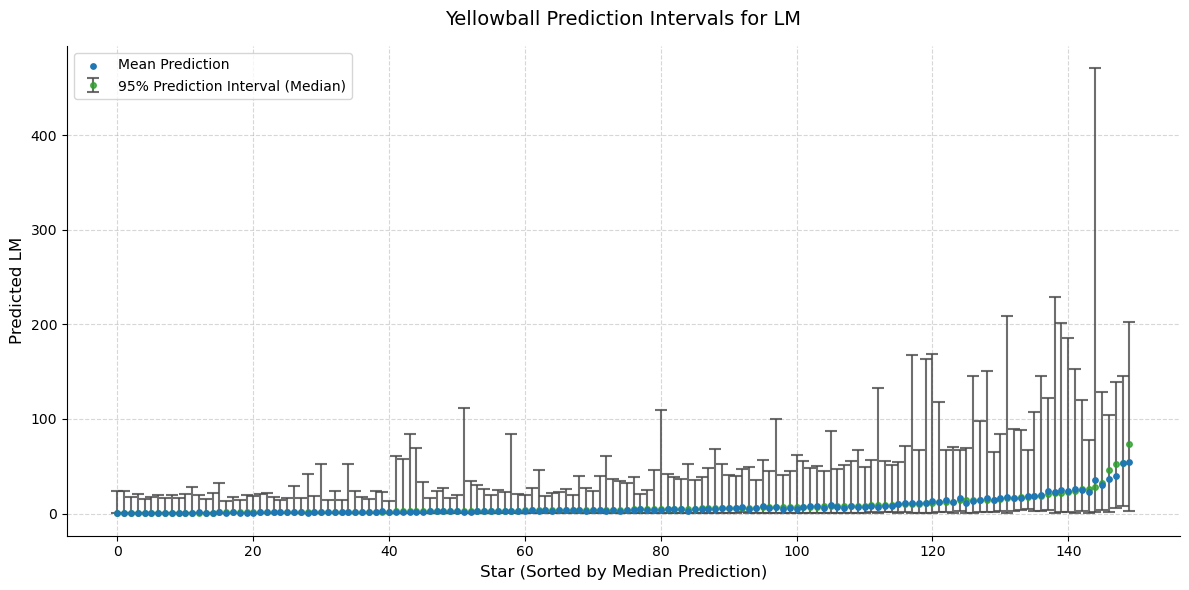

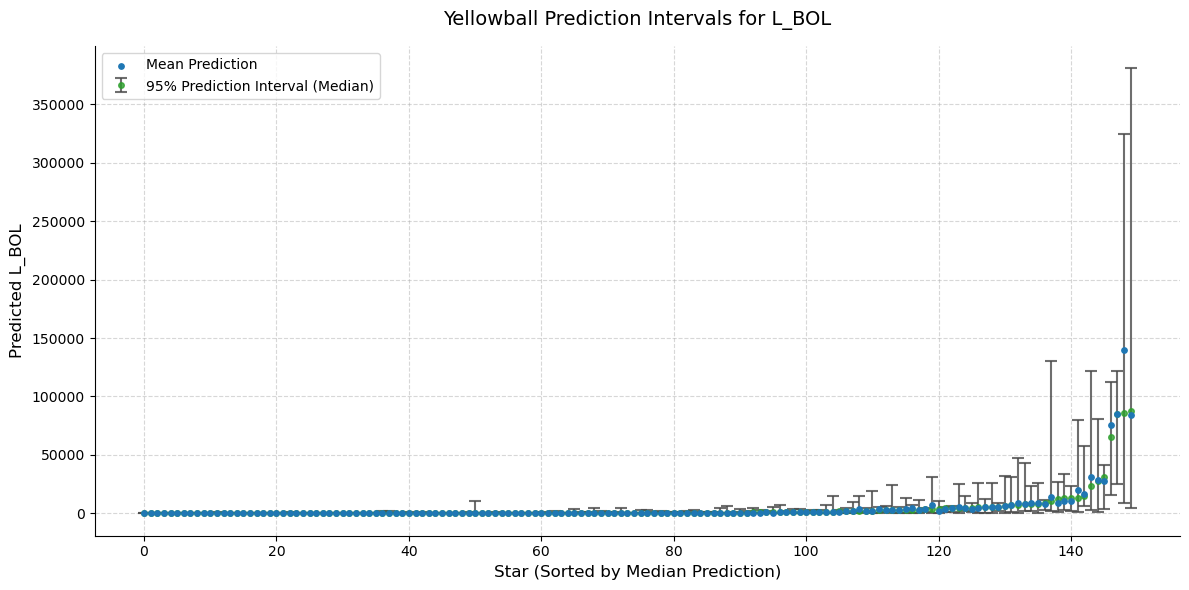

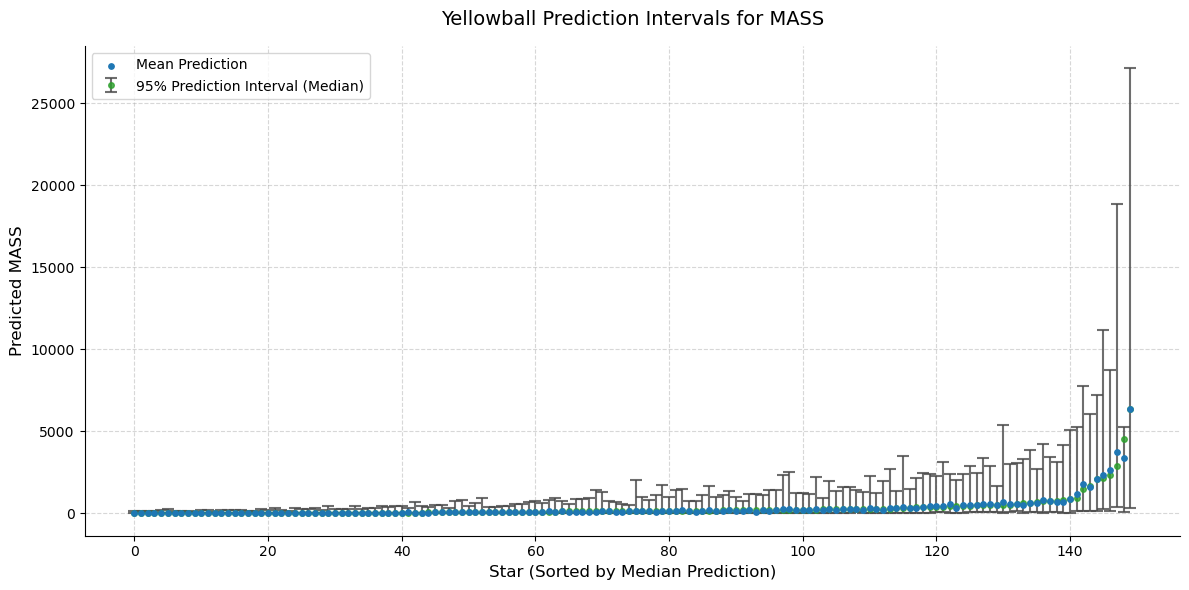

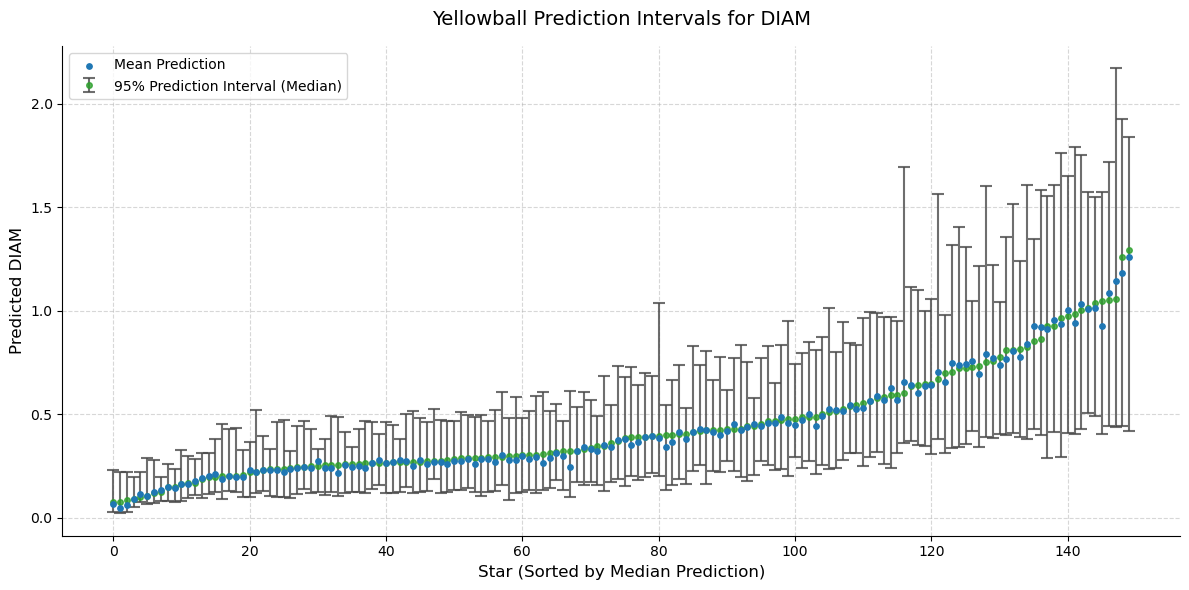

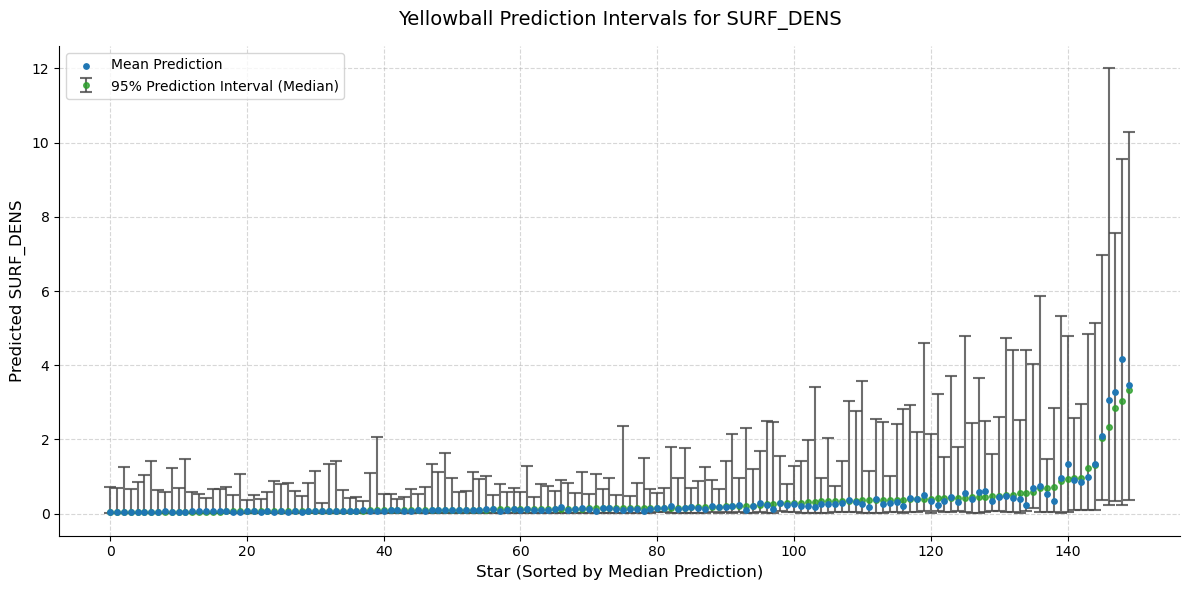

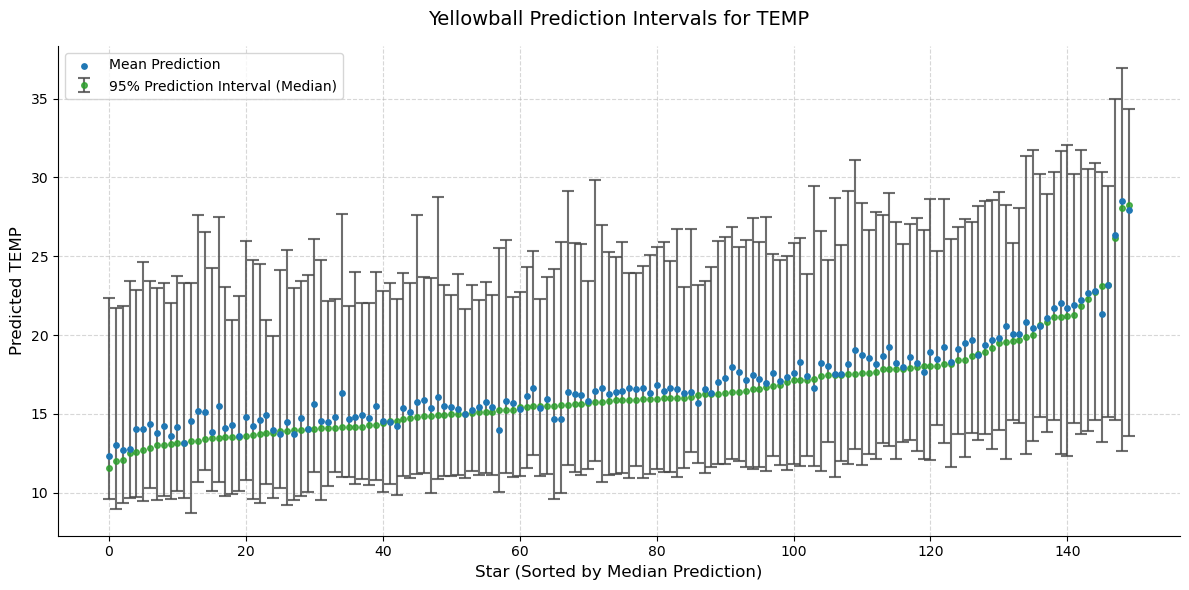

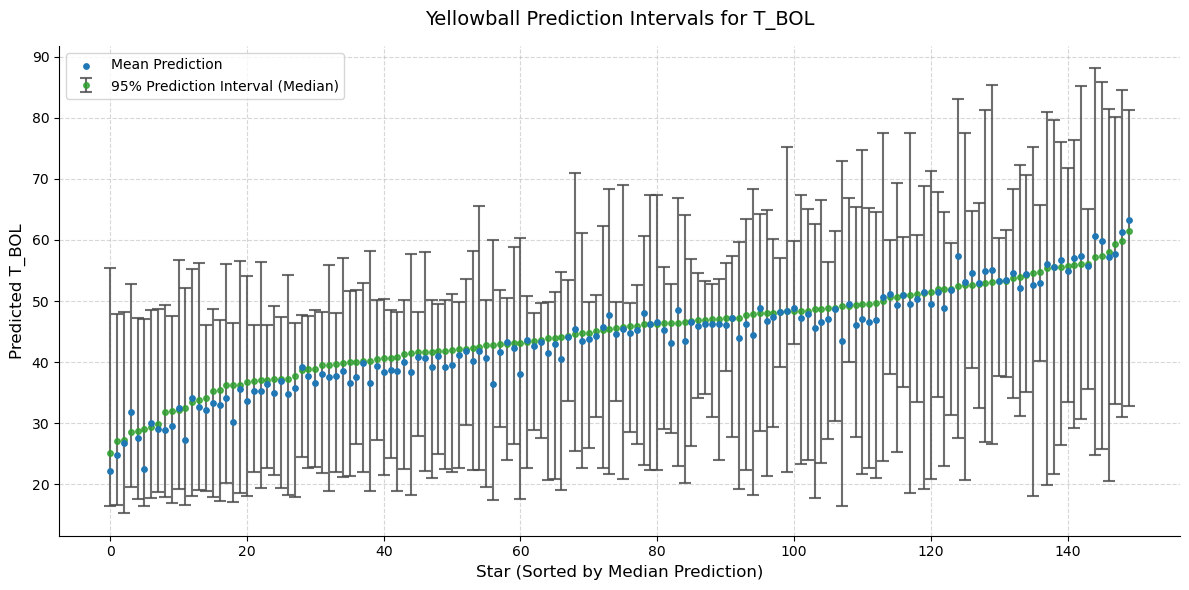

In [9]:
for response in ["LRATIO", "LM", "L_BOL", "MASS", "DIAM", "SURF_DENS", "TEMP", "T_BOL"]:
    data = pd.read_csv(here('predictions', f'{response}_final_predictions.csv'))

    graphing_sample = data.sample(n=150).sort_values(by='median_pred').reset_index(drop=True)

    error_high = graphing_sample['0.975_pred'] - graphing_sample['median_pred']
    error_low = graphing_sample['median_pred'] -graphing_sample['0.025_pred']
    asymmetric_error = [error_low, error_high]

    fig, ax = plt.subplots(figsize=(12, 6))

    plt.errorbar(
    x=graphing_sample.index, 
    y=graphing_sample['median_pred'], 
    yerr=asymmetric_error, 
    fmt='o',             
    markersize=4,
    color='#2CA02C',     # Clear, distinct blue for the median
    ecolor='#4A4A4A',    # Keeping the bars themselves light grey so they don't overpower
    elinewidth=1.5,
    capsize=4,           # Increased from 0 to make the ends visible
    capthick=1.5,        # Added thickness specifically to the caps
    alpha=0.8,
    label='95% Prediction Interval (Median)'
    )
    
    plt.scatter(
    x=graphing_sample.index,
    y=graphing_sample['mean_pred'],
    color='#1F77B4',     # Clear, distinct green for the mean
    s=15, 
    zorder=3,            
    label='Mean Prediction'
    )

    
    ax.set_title(f'Yellowball Prediction Intervals for {response}', fontsize=14, pad=15)
    ax.set_xlabel('Star (Sorted by Median Prediction)', fontsize=12)
    ax.set_ylabel(f'Predicted {response}', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    # Remove top and right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()